## SISTEMAS DE PREDICCIÓN DE RIESGO DE DIABETES MEDIANTE APRENDIZAJE AUTOMÁTICO

### Librerías necesarias para el análisis
> Aquí recopilaré las diferentes librerías que necesite durante el análisis y la implementación de los modelos.

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
import joblib

### 5.1. Adquisición de la fuente de datos

> Como comentamos previamente, la fuente de datos será el Dataset de Kaggle **"Diabetes Health Indicators Dataset"**, autor: CDC, los datos originales sin trabajar provienen de la encuesta BRFSS de 2015 de los CDC, link al dataset: https://www.kaggle.com/code/alexteboul/diabetes-health-indicators-dataset-notebook

In [0]:
# Importamos el dataset
df = pd.read_csv("Diabetes_Data_TFM.csv")

> A continuación expongo la explicación para cada variable, obtenida de la fuente original de los datos y traducida.

**Variables Principales y Diagnósticos**

_Diabetes_012: Variable objetivo (target)_.
- 0: No diabetes.
- 1: Prediabetes.
- 2: Diabetes.

_HighBP: Presión arterial alta._
- 0: No.
- 1: Presión arterial alta.

_HighChol: Colesterol alto._
- 0: No.
- 1: Colesterol alto.

_CholCheck: Chequeo de colesterol._
- 0: No se ha realizado un chequeo en los últimos 5 años.
- 1: Se realizó un chequeo de colesterol en los últimos 5 años.

_BMI: Índice de Masa Corporal (Body Mass Index)._
- Valor numérico continuo (peso en kg dividido por la altura en m2).

**Estilo de Vida y Factores de Riesgo**

_Smoker: Consumo de tabaco._

- 0: No.
- 1: Ha fumado al menos 100 cigarrillos en toda su vida.

_Stroke: Accidente cerebrovascular (ictus)._

- 0: No.
- 1: Ha sufrido un derrame o accidente cerebrovascular.

_HeartDiseaseorAttack: Enfermedad coronaria o ataque cardíaco._

- 0: No.
- 1: Ha tenido una enfermedad coronaria (CHD) o un infarto de miocardio (MI).

_PhysActivity: Actividad física._

- 0: No.
- 1: Ha realizado actividad física o ejercicio en los últimos 30 días (sin contar el trabajo).

_Fruits: Consumo de fruta._

- 0: Consume fruta menos de 1 vez al día.
- 1: Consume fruta 1 o más veces al día.

_Veggies: Consumo de verduras._

- 0: Consume verduras menos de 1 vez al día.
- 1: Consume verduras 1 o más veces al día.

_HvyAlcoholConsump: Consumo elevado de alcohol._

- 0: No.
- 1: Consumo elevado (hombres adultos: más de 14 bebidas por semana; mujeres adultas: más de 7 bebidas por semana).

**Acceso a la Salud y Estado General**

_AnyHealthcare: Cobertura sanitaria._

- 0: No.
- 1: Tiene algún tipo de cobertura de atención médica (seguro de salud, Medicare, Medicaid, etc.).

_NoDocbcCost: Barrera económica para atención médica._

- 0: No.
- 1: Hubo algún momento en los últimos 12 meses en el que necesitó ver a un médico pero no pudo debido al costo.

_GenHlth: Salud general percibida. Escala ordinal del 1 al 5:_

- 1: Excelente 
- 2: Muy buena 
- 3: Buena 
- 4: Regular 
- 5: Mala

_MentHlth: Salud mental deficiente._

- Valor numérico entre 0 y 30: Número de días en los últimos 30 días en los que su salud mental no fue buena (incluye estrés, depresión y problemas emocionales).

_PhysHlth: Salud física deficiente._

- Valor numérico entre 0 y 30: Número de días en los últimos 30 días en los que su salud física no fue buena (incluye lesiones o enfermedades físicas).

_DiffWalk: Dificultad para caminar._

- 0: No.
- 1: Tiene serias dificultades para caminar o subir escaleras.

**Demografía**

_Sex: Sexo biológico._

- 0: Mujer.
- 1: Hombre.

_Age: Rango de edad:_

- 1: Rango de edad (18 a 24 años)  
- 2: Rango de edad (25 a 29 años)  
- 3: Rango de edad (30 a 34 años)  
- 4: Rango de edad (35 a 39 años)  
- 5: Rango de edad (40 a 44 años)  
- 6: Rango de edad (45 a 49 años)  
- 7: Rango de edad (50 a 54 años)  
- 8: Rango de edad (55 a 59 años)  
- 9: Rango de edad (60 a 64 años)  
- 10: Rango de edad (65 a 69 años)  
- 11: Rango de edad (70 a 74 años)  
- 12: Rango de edad (75 a 79 años)  
- 13: Rango de edad (80 años o más)

_Education: Nivel educativo alcanzado. Escala del 1 al 6:_

- 1: Nunca asistió a la escuela o solo guardería.
- 2: Elemental (grados 1 a 8).
- 3: Secundaria incompleta (grados 9 a 11).
- 4: Secundaria completa o equivalente (GED).
- 5: Educación universitaria incompleta (1 a 3 años de universidad o escuela técnica).
- 6: Graduado universitario (4 años o más de universidad).

_Income: Nivel de ingresos anuales del hogar. Escala del 1 al 8:_

- 1: Menos de $10,000  
- 2: $10,000 a <$15,000  
- 3: $15,000 a <$20,000  
- 4: $20,000 a <$25,000  
- 5: $25,000 a <$35,000  
- 6: $35,000 a <$50,000  
- 7: $50,000 a <$75,000  
- 8: $75,000 o más

### 5.2. Descripción de la fuente de datos

> Para describir la fuente de datos, empezaremos por pintar por pantalla su estructura, el tipo de datos que contiene, valores faltantes, duplicados...

In [0]:
print("Shape:", df.shape)

Shape: (253680, 22)


Como podemos ver, el dataset cuenta con 253.680 filas y 22 columnas, un buen número de casos para analizar en profundidad.

In [0]:
print(df.dtypes)

Diabetes_012            float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object


Analizando el tipo de datos podemos ver cómo todos estos son de tipo float, esto anticipa que nos encontramos ante un dataset dónde las variables categóricas han sido convertidas a escala, como se haría en una encuesta dónde por ejemplo, la variable salud se representaría así: 

> **health is: scale 1-5**

 **1 = excellent** 

 **2 = very good** 

 **3 = good** 

 **4 = fair** 

 **5 = poor**

 Esto nos evita codificar las variables de tipo categórico, algo para lo que más adelante analizaré y explicaré cómo y por qué se habrían de haber hecho esas codificaciones.

In [0]:
print(df.isnull().sum())


Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


Se puede observar que los valores nulos no existen en este Dataset, ya que, es una versión limpia de la encuesta BRFSS 2015 de los CDC. Al contar con tal cantidad de datos tampoco nos ahorra demasiado trabajo, ya que, podríamos haber desechado varios nulos sin alterar demasiado el dataset, así mismo como aplicar técnicas de imputación de valores rutinarias como la imputación por la media, valores "desconocidos" o incluso técnicas más avanzadas como imputar valores utilizando el K-nearest neighbors.

In [0]:
print(df.duplicated().sum())

23899


Contamos con un número elevado de valores duplicados (23.899), esto es esperable en una encuesta realizada a un gran número de población. Muchas personas coincidirán en sus respuestas sobre variables tan categóricas.

In [0]:
conteo = df['Diabetes_012'].value_counts()
porcentaje = df['Diabetes_012'].value_counts(normalize=True) * 100

resumen = pd.DataFrame({'Frecuencia': conteo, 'Porcentaje (%)': porcentaje})
print(resumen)

              Frecuencia  Porcentaje (%)
Diabetes_012                            
0.0               213703       84.241170
2.0                35346       13.933302
1.0                 4631        1.825528


> Teniendo en cuenta el significado de los valores de la variable objetivo, anteriormente expuesto:
- 0: No diabetes.
- 1: Prediabetes.
- 2: Diabetes.

Es posible observar como el dataset está enormemente desbalanceado (también lógico y de esperar). El 84% de los casos son personas que no padecen diabetes ni tienen indicios de la enfermedad.

Más adelante, esto es posible que se presente como un problema, puesto que, podríamos caer en un modelo que siempre prediga _No diabetes_ sin ningún tipo de criterio, y en el 84% de los casos acertaría...

La idea es trabajar para que la sensibilidad del modelo sea alta, es decir, que se capaz de predecir con cierta convicción los casos de enfermedad.
En el ámbito médico, estos modelos suelen primar este parámetro por el alto coste que tiene omitir casos de enefermedad, sobre el coste de enviar a un paciente sano a un examen de confirmación.

In [0]:
print(df.describe().T)

                         count       mean       std  ...   50%   75%   max
Diabetes_012          253680.0   0.296921  0.698160  ...   0.0   0.0   2.0
HighBP                253680.0   0.429001  0.494934  ...   0.0   1.0   1.0
HighChol              253680.0   0.424121  0.494210  ...   0.0   1.0   1.0
CholCheck             253680.0   0.962670  0.189571  ...   1.0   1.0   1.0
BMI                   253680.0  28.382364  6.608694  ...  27.0  31.0  98.0
Smoker                253680.0   0.443169  0.496761  ...   0.0   1.0   1.0
Stroke                253680.0   0.040571  0.197294  ...   0.0   0.0   1.0
HeartDiseaseorAttack  253680.0   0.094186  0.292087  ...   0.0   0.0   1.0
PhysActivity          253680.0   0.756544  0.429169  ...   1.0   1.0   1.0
Fruits                253680.0   0.634256  0.481639  ...   1.0   1.0   1.0
Veggies               253680.0   0.811420  0.391175  ...   1.0   1.0   1.0
HvyAlcoholConsump     253680.0   0.056197  0.230302  ...   0.0   0.0   1.0
AnyHealthcare         253

> Investigando un poco sobre el tema, me he dado cuenta que en este dataset tendría sentido convertir la variable _'Diabetes_012'_ en una variale binaria, ya que, la clase minoritaria '**1: Prediabetes**' tan solo cuenta con una representación del 1,8% sobre el total de los datos.

Esto significa que los modelos matemáticos tenderán a "ignorarla" más adelante y simplemente les será más sencillo optimizar sus resultados para las variables mayoritarias.

De este modo, la decisión más lógica, sería predecir como casos de diabetes tanto los casos 1 como los 2. Unificando así ambos como 1.

Ahora la variable quedaría así:

_'Diabetes_01'_
- 0: No
- 1: Diabetes

Y eliminamos por tanto la variable _'Diabetes_012'_

In [0]:
df['Diabetes_01'] = (df['Diabetes_012'] > 0).astype(int)

conteo = df['Diabetes_01'].value_counts()
porcentaje = df['Diabetes_01'].value_counts(normalize=True) * 100

resumen = pd.DataFrame({'Frecuencia': conteo, 'Porcentaje (%)': porcentaje})
print(resumen)

df.drop(columns=['Diabetes_012'], inplace=True)

             Frecuencia  Porcentaje (%)
Diabetes_01                            
0                213703        84.24117
1                 39977        15.75883


In [0]:
# Coloco la variable 'Diabetes_01' en el lugar de su predecesora y volvemos a mostar un .describe()
col = df.pop('Diabetes_01')
df.insert(0, 'Diabetes_01', col)
print(df.describe().T)

                         count       mean       std  ...   50%   75%   max
Diabetes_01           253680.0   0.157588  0.364355  ...   0.0   0.0   1.0
HighBP                253680.0   0.429001  0.494934  ...   0.0   1.0   1.0
HighChol              253680.0   0.424121  0.494210  ...   0.0   1.0   1.0
CholCheck             253680.0   0.962670  0.189571  ...   1.0   1.0   1.0
BMI                   253680.0  28.382364  6.608694  ...  27.0  31.0  98.0
Smoker                253680.0   0.443169  0.496761  ...   0.0   1.0   1.0
Stroke                253680.0   0.040571  0.197294  ...   0.0   0.0   1.0
HeartDiseaseorAttack  253680.0   0.094186  0.292087  ...   0.0   0.0   1.0
PhysActivity          253680.0   0.756544  0.429169  ...   1.0   1.0   1.0
Fruits                253680.0   0.634256  0.481639  ...   1.0   1.0   1.0
Veggies               253680.0   0.811420  0.391175  ...   1.0   1.0   1.0
HvyAlcoholConsump     253680.0   0.056197  0.230302  ...   0.0   0.0   1.0
AnyHealthcare         253

### 5.3. Análisis exploratorio de los datos (EDA)

> Como primer paso para el EDA, voy a proceder a medir las variables numéricas con mayor rango de valores para ver cómo se comportan contra la variable objetivo.

Para ello, vamos a proceder a agrupar individualmente estas variables _('BMI', 'Age', 'GenHlth', 'MentHlth' y 'PhysHlth')_ contra la variable target y observar si son capaces de distinguir si alguien tiene diabetes o no. Es decir, si tienen distribuciones diferentes para los casos con y sin diabetes.

- **Variable BMI (Índice de Masa Corporal)**

> Tanto en la agrupación como en el gráfico, podemos observar como los individuos con diabetes (1) cuentan con un índice de masa corporal más alto en promedio (media de 31,8 frente a 27.7 en los individuos sanos).

Si se observa el gráfio, es fácil ver como el grueso de los individuos con diabetes se sitúa en valores de masa corporal claramente por encima del grupo sano.

No es de extrañar que esta variable vaya a ser una buena candidata para predecir, puesto que, en los estudios clínicos, el sobrepeso es uno de los principales factores de riesgo de la diabetes de tipo II.

In [0]:
df.groupby('Diabetes_01')['BMI'].describe()

,count,mean,std,min,25%,50%,75%,max
Diabetes_01,,,,,,,,
0,213703.0,27.742521,6.260993,12.0,24.0,27.0,30.0,98.0
1,39977.0,31.802737,7.328665,13.0,27.0,31.0,35.0,98.0


/home/spark-5245517e-f4ea-4080-9f1c-fa/.ipykernel/71/command-8230933015470929-4010172657:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diabetes_01', y='BMI', data=df, palette=palette_gray)


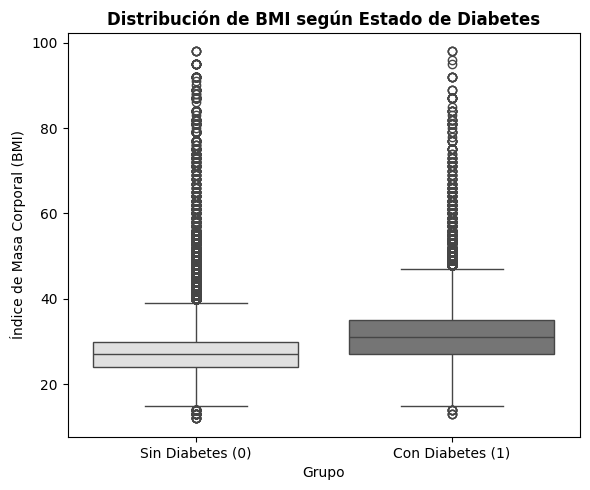

In [0]:
plt.figure(figsize=(6, 5))
palette_gray = ['#e0e0e0', '#757575']
labels = ['Sin Diabetes (0)', 'Con Diabetes (1)']

sns.boxplot(x='Diabetes_01', y='BMI', data=df, palette=palette_gray)
plt.title('Distribución de BMI según Estado de Diabetes', fontweight='bold')
plt.xlabel('Grupo')
plt.ylabel('Índice de Masa Corporal (BMI)')
plt.xticks(ticks=[0, 1], labels=labels)
plt.tight_layout()
plt.show()

- **Variable Age (Edad del sujeto)**

> Se puede observar como la edad del sujeto parece influir también en el riesgo de diabetes. La media de los sujetos con diabetes se sitúa enn el rango de 65 a 69 años, cláramente por encima de los sujetos sanos.

Después de hacer algo de investigación, parece claro que la edad es unos de los principales factores de riesgo de la diabetes de tipo II. 

El umbral de riesgo parece dispararse en el rango de 35 a 45 años. Esto se debe a que con la edad, el cuerpo sufre cambios metabólicos y fisiológicos que hacen que aumente la resistencia a la insulina en las células. La edad también trae consigo algunos cambios conductuales como puede ser el desarrollo de hábitos sedentarios, derivados de la pérdida de masa muscular y energía que se experimenta con la edad, esto constituye un riesgo añadido que agrava aún mássi cabe la intolerancia a la glucosa.


In [0]:
df.groupby('Diabetes_01')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Diabetes_01,,,,,,,,
0,213703.0,7.786559,3.104942,1.0,6.0,8.0,10.0,13.0
1,39977.0,9.344798,2.369167,1.0,8.0,10.0,11.0,13.0


/home/spark-5245517e-f4ea-4080-9f1c-fa/.ipykernel/71/command-8230933015470930-1210493670:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diabetes_01', y='Age', data=df, palette=palette_gray)


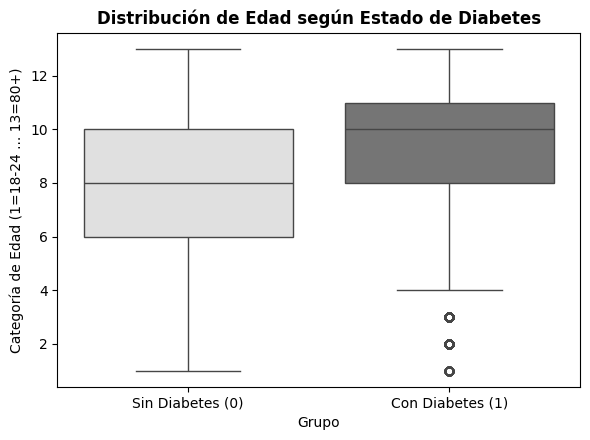

In [0]:
plt.figure(figsize=(6, 4.5))
sns.boxplot(x='Diabetes_01', y='Age', data=df, palette=palette_gray)
plt.title('Distribución de Edad según Estado de Diabetes', fontweight='bold')
plt.xlabel('Grupo')
plt.ylabel('Categoría de Edad (1=18-24 ... 13=80+)')
plt.xticks(ticks=[0, 1], labels=labels)
plt.tight_layout()
plt.show()

- **Variable GenHlth (Salud general del sujeto)**

> Teniendo en cuenta que el 1 representa una buena salud percibida y el 5 la peor. Podemos observar como los individuos del grupo con diabetes tienden a percibirse en peor estado de salud, lo cual tiene sentido.

Los individuos con diabetes presentan peores condiciones de salud general tanto por malos hábitos que pueden llevarles a padecer la enefermedad, como por las propias complicaciones propias de la diabetes (salud mental deficiente, úlceras, infecciones, infecciones más frecuentes...)

Si analizamos el gráfico de barras, podemos ver como en los valores con mejor salud percibida se agrupan la mayoría de individuos que no padecen la enfermedad, mientras que aquellos que sí que la padecen, se agrupan mayoritariamente en los valores 3 y 4 (salud deficiente-mala).

In [0]:
df.groupby('Diabetes_01')['GenHlth'].describe()

,count,mean,std,min,25%,50%,75%,max
Diabetes_01,,,,,,,,
0,213703.0,2.372391,1.019367,1.0,2.0,2.0,3.0,5.0
1,39977.0,3.254446,1.017037,1.0,3.0,3.0,4.0,5.0


<Figure size 700x450 with 0 Axes>

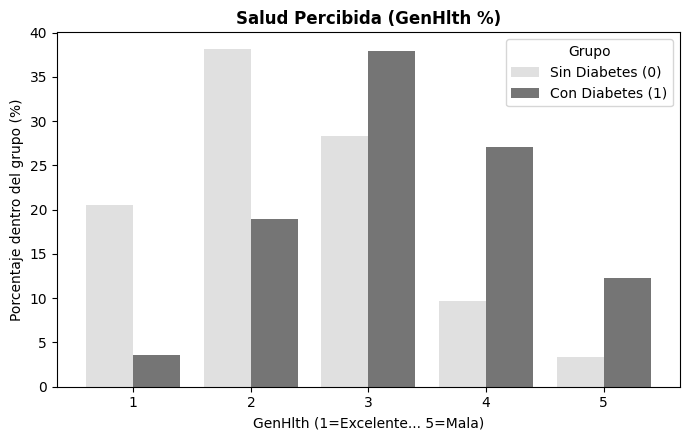

In [0]:
plt.figure(figsize=(7, 4.5))

# Agrupación y cálculo porcentual por columna
df_gen = df.groupby(['Diabetes_01', 'GenHlth']).size().unstack(level=0)
df_gen_pct = df_gen.div(df_gen.sum(axis=0), axis=1) * 100

ax = df_gen_pct.plot(kind='bar', color=palette_gray, width=0.8, figsize=(7, 4.5))
plt.title('Salud Percibida (GenHlth %)', fontweight='bold')
plt.xlabel('GenHlth (1=Excelente... 5=Mala)')
plt.ylabel('Porcentaje dentro del grupo (%)')
plt.xticks(ticks=range(5), labels=[f'{int(x)}' for x in df_gen_pct.index], rotation=0)
plt.legend(labels, title='Grupo')
plt.tight_layout()
plt.show()

- **Variable MentHlth (Salud mental del sujeto)**

> Siguiendo la tendencia de lo anterior con la salud general, es posible ver cómo los sujetos con diabetes suelen tener más días malos de salud a nivel mental que el grupo de control.

En este caso he situado el umbral de días malos en 3 o más, puesto que creo que representa mejor la realidad, en una encuesta como la realizada, parece sencillo contestar que al menos se ha tenido un día malo a nivel de salud mental, pero cuando estos se acumulan, probablemente escondan algo detrás.

Siguiendo esa lógica, decidí establecer el umbral en 3 o más, que creo que es dónde mejor se ve la brecha entre el grupo de control y el grupo de casos.

In [0]:
df.groupby('Diabetes_01')['MentHlth'].describe()

,count,mean,std,min,25%,50%,75%,max
Diabetes_01,,,,,,,,
0,213703.0,2.944404,7.064440,0.0,0.0,0.0,2.0,30.0
1,39977.0,4.469695,8.941793,0.0,0.0,0.0,3.0,30.0


/home/spark-5245517e-f4ea-4080-9f1c-fa/.ipykernel/71/command-8230933015470933-757019357:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df_MentHlth_agrupado.index, y=df_MentHlth_agrupado.values, palette=palette_gray)


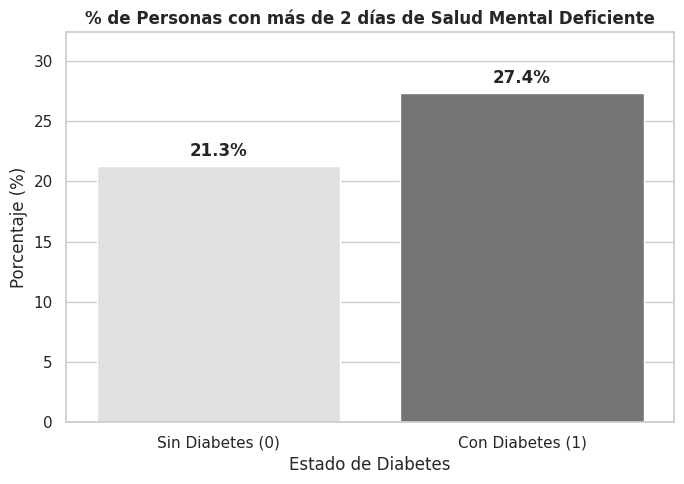

In [0]:
# Cálculo para el porcentaje de personas con > 2 días de salud mental deficiente
df['MentHlth_Problem'] = df['MentHlth'] > 2
df_MentHlth_agrupado = df.groupby('Diabetes_01')['MentHlth_Problem'].mean() * 100

# Configurar el gráfico de barras
plt.figure(figsize=(7, 5))
sns.set_theme(style="whitegrid")

palette = ['#2b5c8f', '#d95f02']
labels = ['Sin Diabetes (0)', 'Con Diabetes (1)']

ax = sns.barplot(x=df_MentHlth_agrupado.index, y=df_MentHlth_agrupado.values, palette=palette_gray)
plt.title('% de Personas con más de 2 días de Salud Mental Deficiente', fontweight='bold')
plt.xlabel('Estado de Diabetes')
plt.ylabel('Porcentaje (%)')
plt.xticks(ticks=[0, 1], labels=labels)
plt.ylim(0, max(df_MentHlth_agrupado.values) + 5)

# Código para añadir los porcentajes a las barras
for i, v in enumerate(df_MentHlth_agrupado.values):
    ax.text(i, v + 0.8, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

- **Variable PhysHlth (Salud física del sujeto)**

> En sintonía con lo anterior, los sujetos que presentan la condición de diabetes, tienden a responder con mayor frecuencia que han sufrido días de condición física deficiente.

In [0]:
df.groupby('Diabetes_01')['PhysHlth'].describe()

,count,mean,std,min,25%,50%,75%,max
Diabetes_01,,,,,,,,
0,213703.0,3.582416,7.999205,0.0,0.0,0.0,2.0,30.0
1,39977.0,7.768417,11.201535,0.0,0.0,1.0,14.0,30.0


/home/spark-5245517e-f4ea-4080-9f1c-fa/.ipykernel/71/command-8230933015470935-455128565:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df_PhysHlth_agrupado.index, y=df_PhysHlth_agrupado.values, palette=palette_gray)


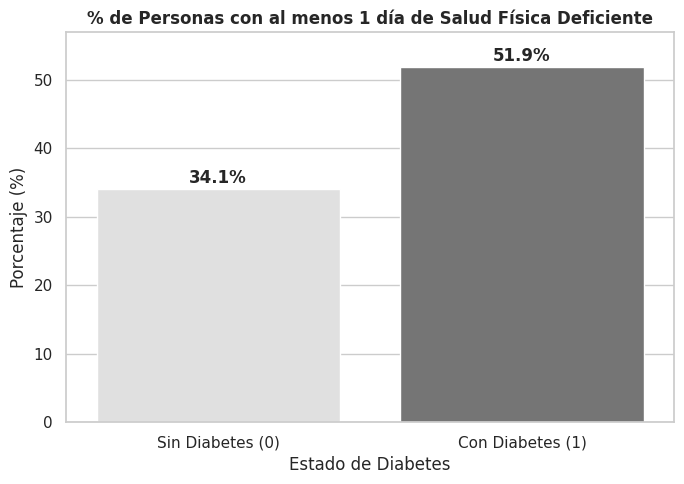

In [0]:
# Cálculo para el porcentaje de personas con > 0 días de salud física deficiente
df['PhsyHlth_Problem'] = df['PhysHlth'] > 0
df_PhysHlth_agrupado = df.groupby('Diabetes_01')['PhsyHlth_Problem'].mean() * 100

# Configurar el gráfico de barras
plt.figure(figsize=(7, 5))
sns.set_theme(style="whitegrid")

palette = ['#2b5c8f', '#d95f02']
labels = ['Sin Diabetes (0)', 'Con Diabetes (1)']

ax = sns.barplot(x=df_PhysHlth_agrupado.index, y=df_PhysHlth_agrupado.values, palette=palette_gray)
plt.title('% de Personas con al menos 1 día de Salud Física Deficiente', fontweight='bold')
plt.xlabel('Estado de Diabetes')
plt.ylabel('Porcentaje (%)')
plt.xticks(ticks=[0, 1], labels=labels)
plt.ylim(0, max(df_PhysHlth_agrupado.values) + 5)

# Código para añadir los porcentajes a las barras
for i, v in enumerate(df_PhysHlth_agrupado.values):
    ax.text(i, v + 0.8, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

> A continuación vamos a observar cómo se distribuyen las variables de tipo binario por grupo. Esto nos da una idea de si la condición que se estudia (variable) puede ser un factor de riesgo o no para la diabetes.

Para ello, seleccionamos las variables binarias que nos quedan, agrupamos en una tabla dividida por grupo y calculamos su media, esto nos dará el porcentaje de sujetos en cada grupo.

In [0]:
binarias = ['HighBP','HighChol','CholCheck','Smoker','Stroke','HeartDiseaseorAttack',
            'PhysActivity','Fruits','Veggies','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex']

tabla = df.groupby('Diabetes_01')[binarias].mean().T*100
tabla_formateada = tabla.map(lambda x: f"{x:.2f}%")
print(tabla_formateada)

Diabetes_01                0       1
HighBP                37.11%  73.83%
HighChol              37.92%  66.44%
CholCheck             95.71%  99.24%
Smoker                42.97%  51.53%
Stroke                 3.16%   8.84%
HeartDiseaseorAttack   7.18%  21.37%
PhysActivity          77.91%  63.61%
Fruits                64.30%  58.74%
Veggies               82.14%  75.79%
HvyAlcoholConsump      6.18%   2.60%
AnyHealthcare         94.97%  95.81%
NoDocbcCost            7.96%  10.86%
DiffWalk              13.23%  36.04%
Sex                   43.40%  47.43%


> De esta tabla podemos extraer una ligera idea de que variables podrían influir fuertemente en nuestros modelos, así, HighBP, HighChol, PhysActivity y DiffWalk, serían las que mayores diferencias muestran.

> Es curioso el caso del consumo elevado de alcohol, pareciera que es menor en pacientes con diabetes que en pacientes sanos. Esto podría ser uno de esos problemas en los que la correlación no implica causalidad. Sería raro pensar que un mayor consumo de alcohol reduce las probabilidades de padecer diabetes.

**Matriz de Correlaciones**

> Procedemos a graficar la matriz de correlaciones como un mapa de calor para tratar de buscar la multicolinealidad y echar un vistazo a cómo se comportan las variables entre ellas.

<Axes: >

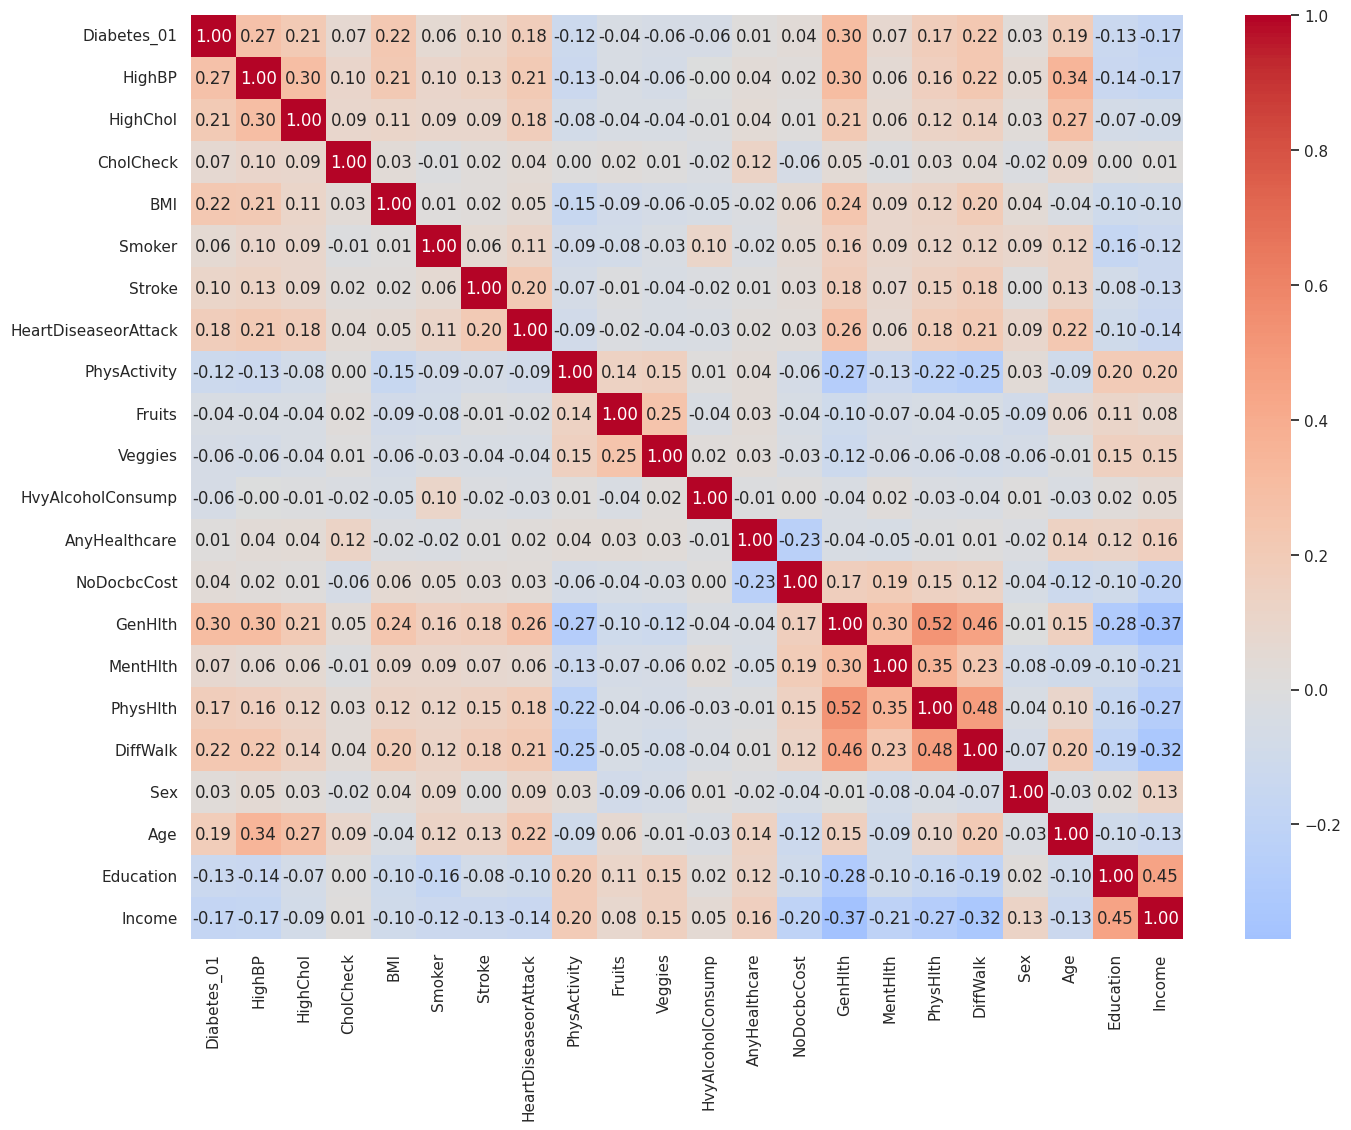

In [0]:
# Elegimos las columnas y sacamos las correlaciones
cols = [c for c in df.columns if c not in ('MentHlth_Problem', 'PhsyHlth_Problem')]
corr = df[cols].corr()

# Graficamos
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)

De aquí podemos sacar varias conclusiones:
- Las variables que más correlación guardan con la variable objetivo son (en orden descendente): **GenHlth (0.30)**, **HighBP (0.27)**, **BMI y DiffWalk (0.22)** y **HighChol (0.21)**.

- Los pares de variables que mayor correlación guardan entre sí (posible multicolinealidad) son: **GenHlth - PhysHlth (0.52)**; **PhysHlth - DiffWalk (0.48)**; **GenHlht - DiffWalk (0.46)** y **Education - Income (0.45)**.

> La multicolinealidad que encontramos en este Dataframe no parece lo suficientemente alarmante como para obligarnos a eliminar variables, pero sí es algo a tener en cuenta por el mayor peso que puedan dar a ciertos modelos al tener una relación moderada.

> Adicionalmente podemos ver como el consumo de frutas y verduras, el sexo, la cobertura sanitaria,la ingesta de alcohol, etc... No parecen tener una relación directa con nuestra variable a predecir.

### 5.4. Preprocesado de los datos

- **Eliminar duplicados**

Pasando al preprocesado de los datos podemos volver sobre el tema de los duplicados. Durante la fase de descripción de la base de datos, se pudo ver como el Dataframe contaba con **23.899 duplicados**.

Como se comentó en su momento, en este tipo de encuestas no es raro encontrarse simples coincidencias a la hora de rellenar los datos, existen ciertas tendencias a la hora de contestar a las preguntas que lleva a la obtención de resultados iguales.

Dado que contamos con un gran número de datos y que eliminar estos duplicados no afectaría gravemente a la calidad y cantidad de los datos, de momento, parece la mejor idea **eliminarlos**. Si más adelante pudiera ocasionar problemas a la hora de predecir, se podría considerar incluirlos de nuevo.

In [0]:
df_unico = df.drop_duplicates()

In [0]:
print("Distribución de la nueva variable binaria:")
print(df_unico['Diabetes_01'].value_counts())
print()
print("Proporción:")
print(df_unico['Diabetes_01'].value_counts(normalize=True).round(4) * 100)

Distribución de la nueva variable binaria:
Diabetes_01
0    190055
1     39657
Name: count, dtype: int64

Proporción:
Diabetes_01
0    82.74
1    17.26
Name: proportion, dtype: float64


> Seguimos contando con una gran cantidad de datos y la proporción se mantiene similar, ligeramente a favor a la hora de predecir los datos, puesto que ahora cuenta con un % algo mayor de casos positivos, lo que en principio debería ayudar a predecir mejor los casos.

- **Tratamiento de Outliers**

Podemos comenzar con el Índice de Masa Coporal (BMI), que como se vio durante el EDA, contaba con numerosos outliers:

/home/spark-5245517e-f4ea-4080-9f1c-fa/.ipykernel/71/command-6672804557361686-1597483887:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diabetes_01', y='BMI', data=df_unico, palette=palette_gray)


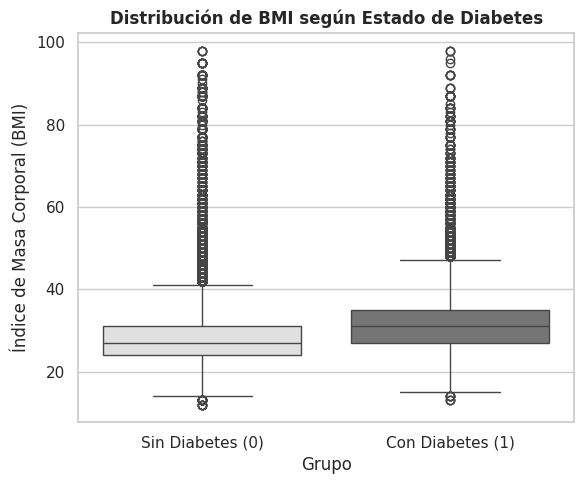

In [0]:
plt.figure(figsize=(6, 5))
palette = ['#2b5c8f', '#d95f02']
labels = ['Sin Diabetes (0)', 'Con Diabetes (1)']

sns.boxplot(x='Diabetes_01', y='BMI', data=df_unico, palette=palette_gray)
plt.title('Distribución de BMI según Estado de Diabetes', fontweight='bold')
plt.xlabel('Grupo')
plt.ylabel('Índice de Masa Corporal (BMI)')
plt.xticks(ticks=[0, 1], labels=labels)
plt.tight_layout()
plt.show()


Se puede ver en el gráfico que no existen valores imposibles, BMIs con valores cercanos a 0 o valores extremádamente exagerados como un BMI de 200, sin embargo, se puede observar que en el extremo alto, realmente existe un gran cola de valores atípicos.

Analizando un poco estos números, los valores por encima de 55-60 son extremádamente raros (sujetos con obesidad extrema, como curiosidad, el humano que registró el BMI más elevado, rondaba los 105...)o podrían deberse incluso a errores en la integridad de los datos.

Es por esto que parece una buena opción windsorizar (susituir valores extremos por un valor más reducido) estos datos para evitar que tomen un peso mayor al que realmente tienen para algunos modelos.

> Se toma el valor de 60 para windosrizar los registros por encima de este, ya que, son extremádamente raros y no aportan mayor peso a las predicciones por ser excepcionalmente altos.

In [0]:
rango_BMI = (df_unico['BMI'] > 60).sum()
print(f"Filas afectadas (BMI > 60): {rango_BMI} ({rango_BMI/len(df)*100:.3f}%)")

df_unico['BMI'] = df_unico['BMI'].clip(upper=60)

print()
print(df_unico['BMI'].describe())

Filas afectadas (BMI > 60): 805 (0.317%)

count    229712.000000
mean         28.629662
std           6.430546
min          12.000000
25%          24.000000
50%          27.000000
75%          32.000000
max          60.000000
Name: BMI, dtype: float64


/home/spark-5245517e-f4ea-4080-9f1c-fa/.ipykernel/71/command-6638960034893116-2940718813:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unico['BMI'] = df_unico['BMI'].clip(upper=60)


In [0]:
df_unico.to_csv("diabetes_preprocesado_30.08.csv", index=False)

> Aunque al principio del estudio hablábamos del desbalanceo de clases, tras binarizar el Dataframe, asumiendo como casos de diabetes aquellos que sufrían una prediabetes, ahora las clases no se encuentran extremádamente desbalanceadas (83% frentre a 17%), con lo cual, no parece necesario generar datos artificiales para que los modelos aprendan un patrón sin caer en falsas conjeturas debidas al desbalanceo.

Cuando apliquemos los modelos de aprendizaje supervisado, podemos utilizar el parámetro **class_weight = 'balanced'** para obligar a los algoritmos a prestar mayor atención a la minoría y castigar más sus errores en esta clase. Al final, como comentamos anteriormente, lo que nos interesa es detectar la mayor cantidad de casos positivos posibles.

### 5.5. Selección de variables

- **Random Forest**

Durante el proceso de EDA se realizó una matriz de correlación para ver la relación directa que guardaban las diferentes variables con nuestra variable objetivo.

Adicionalmente, previo a escoger las variables que serán relevantes para el nodelo, sería bueno realizar un pequeño análisis mediante árboles de decisión, tratando de encontrar algún patrón oculto o combinación de variables que pueda ser útil para separar las clases.

Así, realizamos una copia de nuestro Dataframe, el cual partiremos en una lista con todas las variables candidatas que pueden influir sobre nuestra variable a predecir. Se aplica el Random Forest, y se utiliza el parámetro **class_weight='balanced'** como se comentó anteriormente para dar mayor prioridad a los aciertos sobre la clase minoritaria. 

Lo que nos devuelve es una lista de variables clasificadas de mayor a menor valor, en función de como considera el modelo que están relacionadas con la variable a predecir **'Diabetes_01'**.

In [0]:
df_Random_Forest = df_unico.copy()

# Eliminamos la variable objetivo de la lista de variables candidatas
X = df_Random_Forest.drop(columns=['Diabetes_01'])
y = df_Random_Forest['Diabetes_01']

print("Variables candidatas:", list(X.columns))
print()

# Calculamos la importancia de las variables con Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X, y)
importancia = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("=== Importancia de variables ===")
print(importancia.round(4))

Variables candidatas: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'MentHlth_Problem', 'PhsyHlth_Problem']

=== Importancia de variables ===
BMI                     0.1771
Age                     0.1332
GenHlth                 0.0896
Income                  0.0895
HighBP                  0.0635
Education               0.0634
PhysHlth                0.0577
MentHlth                0.0472
HighChol                0.0367
Fruits                  0.0297
Smoker                  0.0295
Sex                     0.0251
PhysActivity            0.0238
Veggies                 0.0235
DiffWalk                0.0235
HeartDiseaseorAttack    0.0169
NoDocbcCost             0.0130
PhsyHlth_Problem        0.0126
MentHlth_Problem        0.0107
Stroke                  0.0098
HvyAlcoholConsump      

/home/spark-5245517e-f4ea-4080-9f1c-fa/.ipykernel/71/command-8643179673613634-2744564992:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=importancia.values, y=importancia.index, palette='viridis')


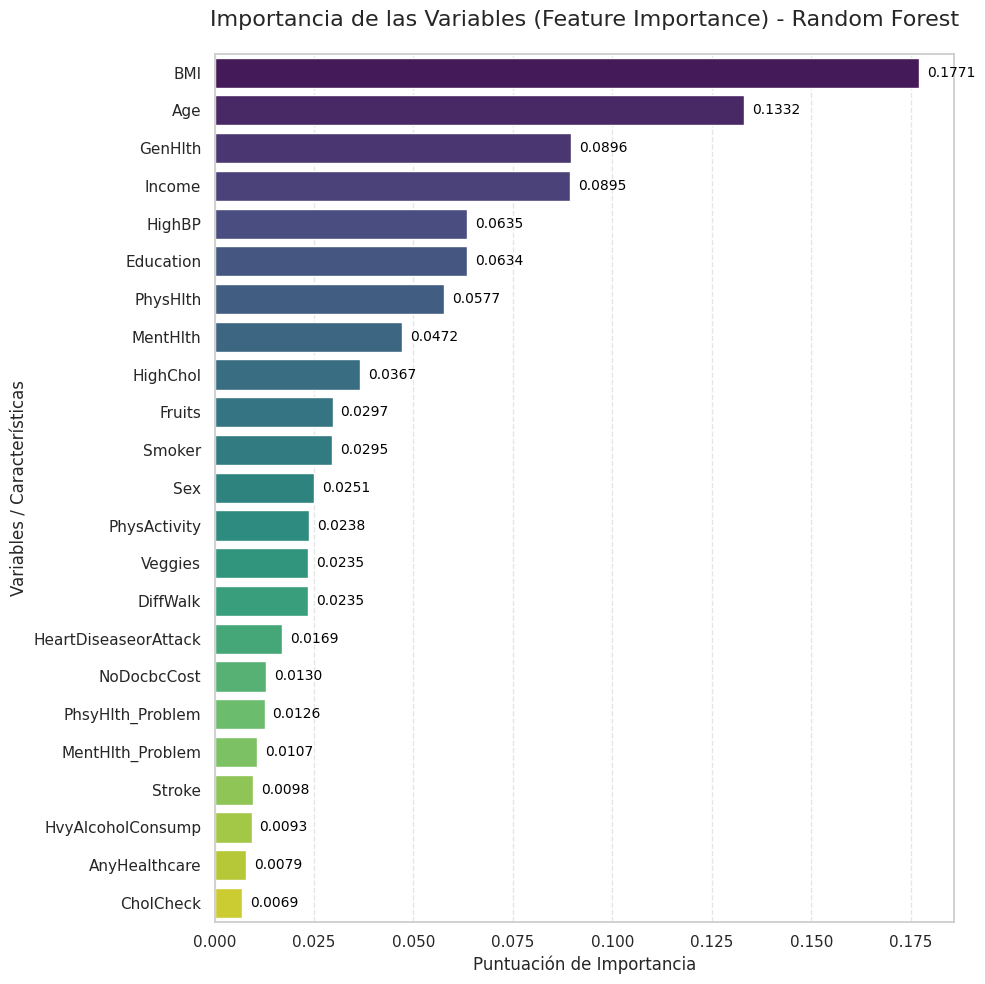

In [0]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 10))

ax = sns.barplot(x=importancia.values, y=importancia.index, palette='viridis')

plt.title('Importancia de las Variables (Feature Importance) - Random Forest', fontsize=16, pad=20)
plt.xlabel('Puntuación de Importancia', fontsize=12)
plt.ylabel('Variables / Características', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)


for i, val in enumerate(importancia.values):
  
    ax.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=10, color='black')

plt.tight_layout()

plt.show()

> Se puede observar como las variables que más peso tienen, serían el Índice de masa corporal **(BMI)** y la Edad **(Age)**, seguidas de otras variables como **GenHlth** o **Income**.

Si nos damos cuenta, mantienen cierta relación con las que comentamos durante el EDA, tomando algunas de ellas como **Age** o **Income** más peso en los árboles de decisión, ya que, están teniendo en cuenta relaciones no lineales entre vaiables.

Por poner un ejemplo, la variable Salario **(Income)** podría estar relacionada de manera que un menor salario, conllevaría una peor alimentación, unos hábitos menos saludables, menor tiempo para realizar ejercicio físico, etc... Hábitos, que hoy día están reconocidos como factores de riesgo para el desarrollo de la diabetes de tipo II.

- **Información mutua**

Cómo último estadístico podemos utilizar un algoritmo de información mutua, para tratar de encontrar relaciones individuales, lineales y no lineales, que puedan presentar las variables analizadas con la variable a predecir. Esto es un punto más allá que el proceso realizado durante el EDA, puesto que también incluye las relaciones no lineales de cada variable individualmente.

Seguimos los mismos pasos que en el apartado anterior, pero esta vez aplicamos un algoritmo de información mutua.

In [0]:
df_Mutual_Info = df_unico.copy()

# Eliminamos la variable objetivo de la lista de variables candidatas
X = df_Mutual_Info.drop(columns=['Diabetes_01'])
Y = df_Mutual_Info['Diabetes_01']

mi = mutual_info_classif(X, Y, discrete_features='auto', random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print("=== Información mutua con la variable objetivo ===")
print(mi_series.round(4))

=== Información mutua con la variable objetivo ===
HighBP                  0.0539
GenHlth                 0.0493
AnyHealthcare           0.0464
CholCheck               0.0431
PhysActivity            0.0423
HighChol                0.0385
Veggies                 0.0369
Fruits                  0.0335
BMI                     0.0293
Age                     0.0268
Smoker                  0.0225
PhsyHlth_Problem        0.0218
Sex                     0.0211
DiffWalk                0.0208
Education               0.0189
Income                  0.0182
PhysHlth                0.0135
HeartDiseaseorAttack    0.0134
MentHlth_Problem        0.0065
Stroke                  0.0044
MentHlth                0.0041
HvyAlcoholConsump       0.0026
NoDocbcCost             0.0015
dtype: float64


/home/spark-5245517e-f4ea-4080-9f1c-fa/.ipykernel/71/command-8643179673613635-3668783233:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis')


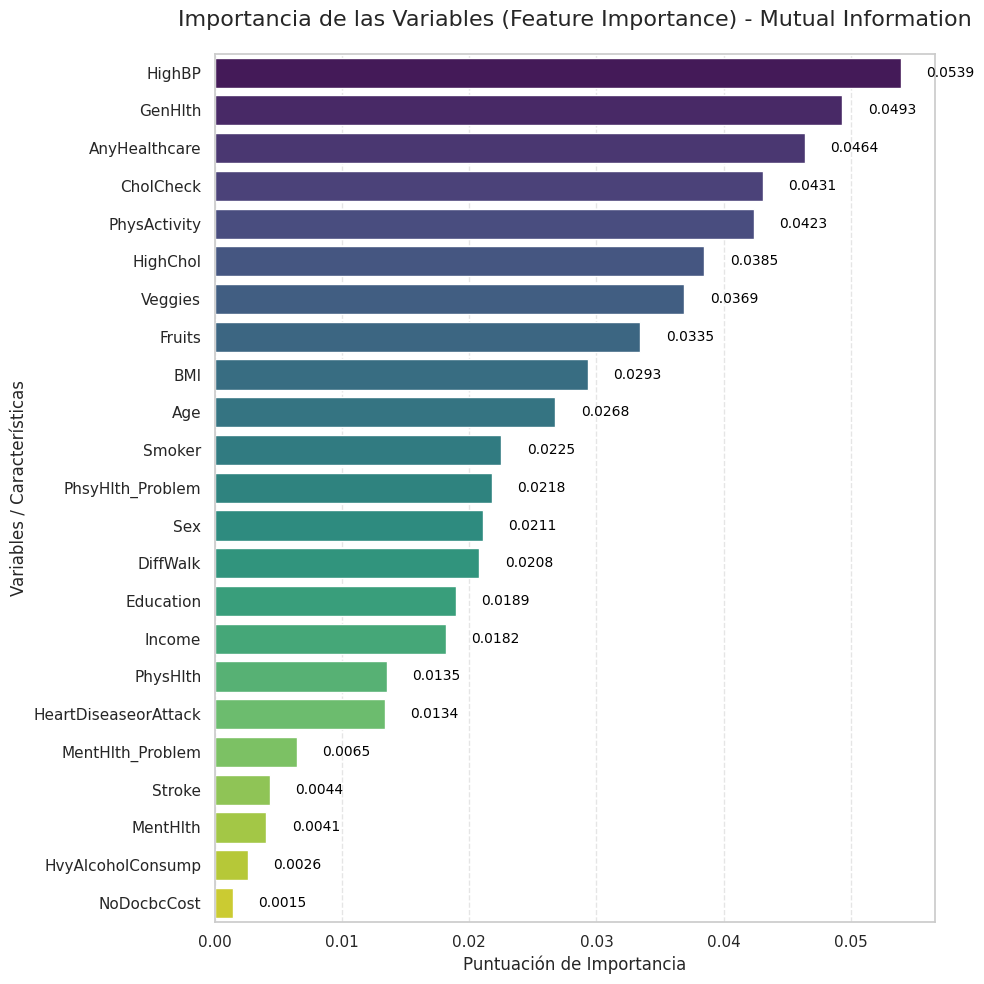

In [0]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 10))

ax = sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis')

plt.title('Importancia de las Variables (Feature Importance) - Mutual Information', fontsize=16, pad=20)
plt.xlabel('Puntuación de Importancia', fontsize=12)
plt.ylabel('Variables / Características', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)


for i, val in enumerate(mi_series.values):
  
    ax.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=10, color='black')

plt.tight_layout()

plt.show()

Es curioso como la clasificación cambia radicalmente con este algoritmo de información mutua, y variables como **'AnyHealthcare' y 'ColCheck'**, que en Random Forest aparecían en los últimos puestos, aquí muestran mucha mayor relevancia siendo de las principales.

Variables como **'Stroke', 'HvyAlcoholConsump' y 'NoDocbcCost'** se muestran bastante bajas en los 3 análisis que hemos realizado, con lo cual, la mejor opción, probablemente sea eliminarlas de los modelos.

> De aquí sacamos la conclusión de la importancia que tiene aplicar diversas técnicas para analizar la importancia de las variables, puesto que, diferentes criterios de análisis, nos han aportado diferentes resultados de relación. Haciendo aún más visibles las variables que manifiestamente se han comportado mal en todos los tipos de análisis.

La opción que voy a tomar en este paso es eliminar las 3 variables que consistentemente han mostrado una relación débil con la variable a predecir, de este modo, nos quitaríamos posible ruido a la hora de probar los modelos. Siguiendo el principio de la Navaja de Ockham, siempre preferiremos el modelo más simple, que mantenga el mismo rendimiento.

> Más adelante podría plantearse eliminar alguna variable extra en específico para cada modelo. Por ejemplo, para un modelo lineal, convendría eliminar variables con una mayor correlación entre sí.



In [0]:
df_filtrado = df_unico.copy()

# Eliminamos las variables con puntuación débil
df_filtrado = df_filtrado.drop(columns = ['Stroke','HvyAlcoholConsump','NoDocbcCost','MentHlth_Problem','PhsyHlth_Problem'])

print("Columnas antes:", df_unico.shape[1])
print("Columnas después:", df_filtrado.shape[1])
print()
print("Variables finales para el modelado:")
print([c for c in df_filtrado.columns if c not in ['Diabetes_01']])

df_filtrado.to_csv("diabetes_seleccion_variables.csv", index=False)
print()
print("Guardado")

Columnas antes: 24
Columnas después: 19

Variables finales para el modelado:
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'AnyHealthcare', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Guardado


### 5.6. Partición en Train y Test

> Partimos el Dataframe en datos de Test y Train, utilzamos el parámetro **stratify=y** para mantener la proporción de clases y no desbalancear tras la selección aleatoria. Comprobamos que efectivamente ha funcionado y los datos muestran la misma proproción de clases tanto en Train como Test.

In [0]:
X = df_filtrado.drop(columns=['Diabetes_01'])
y = df_filtrado['Diabetes_01']

#Stratify para mantener la proporción en train y test y que por aleatoriedad no haya clases desbalanceadas
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamaño train:", X_train.shape, " Tamaño test:", X_test.shape)
print()
print("Proporción de clases en train:")
print(y_train.value_counts(normalize=True).round(4)*100)
print()
print("Proporción de clases en test:")
print(y_test.value_counts(normalize=True).round(4)*100)

Tamaño train: (183769, 18)  Tamaño test: (45943, 18)

Proporción de clases en train:
Diabetes_01
0    82.74
1    17.26
Name: proportion, dtype: float64

Proporción de clases en test:
Diabetes_01
0    82.74
1    17.26
Name: proportion, dtype: float64


> Procedemos a escalar las variables no binarias, para ello ajustamos y escalamos los datos de Train y luego escalamos en Test utilizando los valores previamente obtenidos.

> Las medias en Train deberían ser iguales a 0, ya que el escalador se ajustó con esos datos, sin embargo, y si hemos escalado y previamente proporcionado correctamente las clases, las medias de Test deberían ser ligeramente distintas de 0.

In [0]:
# Escalado: Solo en train, y aplicar a train y test
cols_numericas = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Ajustar con train y escalar en test con los mismos valores que descubrimos en train
X_train_scaled[cols_numericas] = scaler.fit_transform(X_train[cols_numericas])
X_test_scaled[cols_numericas] = scaler.transform(X_test[cols_numericas])

# Comprobamos que las medias son 0
print()
print("Comprobación - medias en train tras escalar")
print(X_train_scaled[cols_numericas].mean().round(3))
print()
print("Comprobación - medias en test tras escalar")
print(X_test_scaled[cols_numericas].mean().round(3))

# Guardamos los datos para poder aplicarlos en el futuro a cada modelo
X_train_scaled.to_csv("X_train.csv", index=False)
X_test_scaled.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)
joblib.dump(scaler, "scaler.pkl")
print()
print("Ficheros guardados")


Comprobación - medias en train tras escalar
BMI         -0.0
GenHlth     -0.0
MentHlth     0.0
PhysHlth    -0.0
Age          0.0
Education   -0.0
Income       0.0
dtype: float64

Comprobación - medias en test tras escalar
BMI         -0.008
GenHlth     -0.008
MentHlth     0.010
PhysHlth    -0.009
Age         -0.010
Education    0.017
Income       0.011
dtype: float64

Ficheros guardados


### 5.7. Aplicación de modelos de aprendizaje automático

Toca seleccionar los modelos que aplicaremos a nuestros datos, en este caso, y con motivos didácticos, he seleccionado 5 modelos diferentes:

- Un modelo base, en este caso una **Regresión Logística**.

- Un modelo basado en distancias como pueda ser **K-Nearest Neighbors**.

- 2 modelos basados en árboles: **Random Forest** y **Gradient Boosting**.

- Y un modelo de **Red Neuronal Simple** para buscar relaciones que hayan podido quedar ocultas en los anteriores.

In [0]:
#Importamos los datos que guardamos en el paso anterior
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

> Generamos una función que permita reportar los resultados de cada modelo en el mismo formato y con los mismos parámetros, al menos, todos aquellos que cada modelo permita.

In [0]:
# Diccionarios para guardar los resultados de cada modelo y sus probabilidades
# Lo coloco aquí puesto que al importar y reinicializar evaluación.py, se reinicializa el diccionario
resultados = {}
prob_modelos = {}

In [0]:
%%writefile evaluacion.py
#Creo un ejecutable con la función

import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
 
def evaluar_modelo(nombre, modelo, X_test, y_test, y_pred=None, y_proba=None):
    """
    Funcioón para calcular el mismo conjunto de métricas para cualquier modelo entrenado
    y las guarda en el diccionario 'resultados'.
    """
    if y_pred is None: #Calcula si ya le hemos pasado las clases predichas, si no, las calcula.
        y_pred = modelo.predict(X_test)
    if y_proba is None: #Comprueba si le hemos pasado las probabilidades cotninuas, si no, las calcula.
        if hasattr(modelo, "predict_proba"): #Coo no todos los modelos soportan prob. pregunta si soporta el método predict_proba y actua en consecuencia.
            y_proba = modelo.predict_proba(X_test)[:, 1]
        else:
            y_proba = None
 
    """Diccionario ccon las distintas métricas a calcular, además, si el modelo cuenta con y_proba con probabilidades contínuas, aáde el método Auc-Roc"""
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
    }
    if y_proba is not None:
        metrics["auc_roc"] = roc_auc_score(y_test, y_proba)
 
    """Guardamos las métricas en el diccionario resultados"""
    #resultados[nombre] = metrics
 
    """Imprimimos las métricas con 4 decimales, realizamos su matriz de confusión y el reporte de clasificación"""
    print(f"--- {nombre} ---")
    for k, v in metrics.items():
        print(f"{k:10s}: {v:.4f}")
    print()
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    print()
    print(classification_report(y_test, y_pred, target_names=["Sin diabetes", "Diabetes/prediab."]))
    print("-" * 60)
 
    return metrics

Overwriting evaluacion.py


- **Regresión Logística**

> Empleamos el parámetro **class_weight='balanced'** como comentamos anteriormente para penalizar más los errores en l clase minoritaria y que el modelo adquiera una mayor sensibilidad (*recall*)

In [0]:
import sys
import importlib
import pandas as pd
import joblib
from sklearn.linear_model import LogisticRegression

# Añadir el directorio actual y forzar la recarga de evaluacion.py
sys.path.append('.')
import evaluacion
importlib.reload(evaluacion)

from evaluacion import evaluar_modelo

# Cargamos los datos preprocesados
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

# Realizamos la Regresión Logística
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Evaluamos el modelo
evaluar_modelo("Regresión Logística", log_reg, X_test, y_test)

prob_modelos['Regresión logística'] = log_reg.predict_proba(X_test)[:, 1]
resultados['Regresión Logística'] = evaluar_modelo("Regresión Logística", log_reg, X_test, y_test)

# Guardamos el modelo entrenado
joblib.dump(log_reg, "modelo_logreg.pkl")

--- Regresión Logística ---
accuracy  : 0.7180
precision : 0.3497
recall    : 0.7374
f1        : 0.4744
auc_roc   : 0.8004

Matriz de confusión:
[[27136 10875]
 [ 2083  5849]]

                   precision    recall  f1-score   support

     Sin diabetes       0.93      0.71      0.81     38011
Diabetes/prediab.       0.35      0.74      0.47      7932

         accuracy                           0.72     45943
        macro avg       0.64      0.73      0.64     45943
     weighted avg       0.83      0.72      0.75     45943

------------------------------------------------------------
--- Regresión Logística ---
accuracy  : 0.7180
precision : 0.3497
recall    : 0.7374
f1        : 0.4744
auc_roc   : 0.8004

Matriz de confusión:
[[27136 10875]
 [ 2083  5849]]

                   precision    recall  f1-score   support

     Sin diabetes       0.93      0.71      0.81     38011
Diabetes/prediab.       0.35      0.74      0.47      7932

         accuracy                           0.72 

['modelo_logreg.pkl']

Analizando los datos, se puede observar como el modelo cuenta con una **Accuracy del 72%**, esto significa que nuestro modelo predice en general peor de lo que un *"modelo tonto"*, lo haría, ya que, con tan solo indicar siempre que todos los casos son pacientes sin diabetes, estaríamos acertando en el 83% de los casos.

La **Precisión del 35%** es nuestro precio a pagar por el desbalanceo de clases y enfocarnos en predecir la clase minoritaria. Esto significa que, **de cada 100 positivos únicamente 35 serían reales**, el resto serían falsos positivos.

En cuanto a la sensibilidad o **Recall** del modelo, el modelo es capaz de detectar el **74% de los casos** positivos, esto es 3 de cada 4 pacientes.

La métrica **AUC-ROC**, por encima del **80%**, parece un número relativamente razonable para modelos médicos obtenidos de encuestas, ya solo con unas simples preguntas, estaríamos asignando con un 80% de probabilidad una mayor probabilidad estimada de diabetes al paciente enfermo que al sano.

- **K-Nearest Neighbors**

> Importante recalcar que KNN no cuenta con un parámetro de balanceo de clases nativo

In [0]:
import sys
import importlib
import pandas as pd
import joblib
from sklearn.neighbors import KNeighborsClassifier

sys.path.append('.')
import evaluacion
importlib.reload(evaluacion)

from evaluacion import evaluar_modelo

X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

k_nearest = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
k_nearest.fit(X_train, y_train)

evaluar_modelo("KNN", k_nearest, X_test, y_test)

prob_modelos['KNN'] = k_nearest.predict_proba(X_test)[:, 1]
resultados['KNN'] = evaluar_modelo("KNN", k_nearest, X_test, y_test)

joblib.dump(k_nearest, "modelo_knn.pkl")

--- KNN ---
accuracy  : 0.8296
precision : 0.5174
recall    : 0.1913
f1        : 0.2793
auc_roc   : 0.7663

Matriz de confusión:
[[36596  1415]
 [ 6415  1517]]

                   precision    recall  f1-score   support

     Sin diabetes       0.85      0.96      0.90     38011
Diabetes/prediab.       0.52      0.19      0.28      7932

         accuracy                           0.83     45943
        macro avg       0.68      0.58      0.59     45943
     weighted avg       0.79      0.83      0.80     45943

------------------------------------------------------------
--- KNN ---
accuracy  : 0.8296
precision : 0.5174
recall    : 0.1913
f1        : 0.2793
auc_roc   : 0.7663

Matriz de confusión:
[[36596  1415]
 [ 6415  1517]]

                   precision    recall  f1-score   support

     Sin diabetes       0.85      0.96      0.90     38011
Diabetes/prediab.       0.52      0.19      0.28      7932

         accuracy                           0.83     45943
        macro avg     

['modelo_knn.pkl']

 En este caso la **Accuracy** es cláramente superior a la regresión, sin embargo, no es el dato que buscamos, puesto que de nada nos sirve predecir con exactitud la clase mayoritaria si erramos estrepitósamente al detectar enfermos.

 La **Precisión** en este modelo es de entorno al 50%, es decir, de cada 100 casos que asignamos como positivos, 50 serían positivos reales y el resto falsos positivos.

 Por último, podemos ver como este modelo no cumpliría con nuestros criterios para detectar positivos, puesto que con un **Recall del 18%**, estaría errando enormemente a la hora de predecir positivos, asignandolos como pacientes sanos cuando realmente no lo son. De **7900 casos positivos reales, tan solo diagnostica correctamente a 1400**, como se puede observar en la matriz de confusión.

- **Random Forest**

> Volvemos a aplicar el parámetro *class_weight='balanced'*, sin embargo, parece ser que el criterio de balanceo de Random Forest difiere ligeramente del usado por modelos de Regresión.
Esto ocurre ya que en random forest no minimiza la función de pérdida, penalizando más a la clase minoritaria como en Regresión.

> Aquí lo que ocurre es que los árboles entrenan con una submuestra del tamñano de los datos originales, esto hace que solo unos pocos árboles asignen mucho peso a unas pocas observaciones, lo cual, no es suficiente para que en el conjunto de decisiones el modelo sea capaz de votar con mayor fuerza por la clase minoritaria.

> Más adelante intentaremos arreglar este problema para conseguir favorecer en mayor medida la detección de casos positivos.

In [0]:
import sys
import importlib
import time
import pandas as pd
import joblib

from sklearn.ensemble import RandomForestClassifier

sys.path.append('.')
import evaluacion
importlib.reload(evaluacion)

from evaluacion import evaluar_modelo

X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

t0 = time.time()
random_forest = RandomForestClassifier(
    n_estimators=300, max_depth=None, class_weight='balanced',
    random_state=42, n_jobs=-1
)
random_forest.fit(X_train, y_train)
print(f"Tiempo de entrenamiento: {time.time()-t0:.1f}s")

evaluar_modelo("Random Forest", random_forest, X_test, y_test)

prob_modelos['Random Forest'] = random_forest.predict_proba(X_test)[:, 1]
resultados['Random Forest'] = evaluar_modelo("Random Forest", random_forest, X_test, y_test)

joblib.dump(random_forest, "modelo_rf.pkl")

Tiempo de entrenamiento: 32.3s
--- Random Forest ---
accuracy  : 0.8235
precision : 0.4716
recall    : 0.1853
f1        : 0.2661
auc_roc   : 0.7692

Matriz de confusión:
[[36364  1647]
 [ 6462  1470]]

                   precision    recall  f1-score   support

     Sin diabetes       0.85      0.96      0.90     38011
Diabetes/prediab.       0.47      0.19      0.27      7932

         accuracy                           0.82     45943
        macro avg       0.66      0.57      0.58     45943
     weighted avg       0.78      0.82      0.79     45943

------------------------------------------------------------
--- Random Forest ---
accuracy  : 0.8235
precision : 0.4716
recall    : 0.1853
f1        : 0.2661
auc_roc   : 0.7692

Matriz de confusión:
[[36364  1647]
 [ 6462  1470]]

                   precision    recall  f1-score   support

     Sin diabetes       0.85      0.96      0.90     38011
Diabetes/prediab.       0.47      0.19      0.27      7932

         accuracy             

['modelo_rf.pkl']

Como comentado, el modelo no es capaz de balancear bien las clases y por ende, adquiere unos resultados bastante similares a los de KNN, siendo bastante mediocre en la detección de casos de diabtes con tan solo un **18% de Recall**

- **Gradient Boosting**

> Sobre el papel, Gradient Boosting debería ser nuestro mejor modelo, dado que solventaría el principal problema de Random Forest para modelos desbalanceados.

In [0]:
import sys
import importlib
import time
import pandas as pd
import joblib

from sklearn.ensemble import HistGradientBoostingClassifier

sys.path.append('.')
import evaluacion
importlib.reload(evaluacion)

X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

t0 = time.time()
gradient_boost = HistGradientBoostingClassifier(
    max_iter=300, class_weight='balanced', random_state=42
)
gradient_boost.fit(X_train, y_train)
print(f"Tiempo de entrenamiento: {time.time()-t0:.1f}s")

evaluar_modelo("Gradient Boosting", gradient_boost, X_test, y_test)

prob_modelos['Gradient Boosting'] = gradient_boost.predict_proba(X_test)[:, 1]
resultados['Gradient Boosting'] = evaluar_modelo("Gradient Boosting", gradient_boost, X_test, y_test)

joblib.dump(gradient_boost, "modelo_gb.pkl")

Tiempo de entrenamiento: 4.5s
--- Gradient Boosting ---
accuracy  : 0.7101
precision : 0.3457
recall    : 0.7603
f1        : 0.4753
auc_roc   : 0.8089

Matriz de confusión:
[[26594 11417]
 [ 1901  6031]]

                   precision    recall  f1-score   support

     Sin diabetes       0.93      0.70      0.80     38011
Diabetes/prediab.       0.35      0.76      0.48      7932

         accuracy                           0.71     45943
        macro avg       0.64      0.73      0.64     45943
     weighted avg       0.83      0.71      0.74     45943

------------------------------------------------------------
--- Gradient Boosting ---
accuracy  : 0.7101
precision : 0.3457
recall    : 0.7603
f1        : 0.4753
auc_roc   : 0.8089

Matriz de confusión:
[[26594 11417]
 [ 1901  6031]]

                   precision    recall  f1-score   support

     Sin diabetes       0.93      0.70      0.80     38011
Diabetes/prediab.       0.35      0.76      0.48      7932

         accuracy      

['modelo_gb.pkl']

Efectivamente, nuestro modelo de Gradient Boosting base es el modelo que mejor desempeño general y que mayor sensibilidad ha demostrado hasta ahora.

Con un **Recall de 76%**, estaríamos acertando el diagnóstico para el 76% de los pacientes que realmente cuentan con la enfermedad.

La explicación para esto viene por la forma en que trabajan los árboles de Gradient Boosting frente a los de Random Forest, mientras que en el segundo se ejecutan todos a la vez y la decisión se toma por mayoría, **en Gradient Boosting, los árboles se ejecutan uno tras otro, donde el siguiente trata de corregir los errores cometidos por el anterior**, esto hace que el modelo se centre cada vez más en los casos más complejos de detectar.

- **Red Neuronal**

In [0]:
import sys
import importlib
import time
import pandas as pd
import joblib

from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight

sys.path.append('.')
import evaluacion
importlib.reload(evaluacion)

X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

t0 = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=(32,16), activation='relu', max_iter=200,
    random_state=42, early_stopping=True
)
mlp.fit(X_train, y_train)
print(f"Tiempo de entrenamiento: {time.time()-t0:.1f}s")

evaluar_modelo("Red Neuronal (MLP)", mlp, X_test, y_test)

prob_modelos['Red Neuronal (MLP)'] = mlp.predict_proba(X_test)[:, 1]
resultados['Red Neuronal (MLP)'] = evaluar_modelo("Red Neuronal (MLP)", mlp, X_test, y_test)

joblib.dump(mlp, "modelo_mlp.pkl")

Tiempo de entrenamiento: 6.2s
--- Red Neuronal (MLP) ---
accuracy  : 0.8386
precision : 0.5968
recall    : 0.2005
f1        : 0.3001
auc_roc   : 0.8063

Matriz de confusión:
[[36937  1074]
 [ 6342  1590]]

                   precision    recall  f1-score   support

     Sin diabetes       0.85      0.97      0.91     38011
Diabetes/prediab.       0.60      0.20      0.30      7932

         accuracy                           0.84     45943
        macro avg       0.73      0.59      0.60     45943
     weighted avg       0.81      0.84      0.80     45943

------------------------------------------------------------
--- Red Neuronal (MLP) ---
accuracy  : 0.8386
precision : 0.5968
recall    : 0.2005
f1        : 0.3001
auc_roc   : 0.8063

Matriz de confusión:
[[36937  1074]
 [ 6342  1590]]

                   precision    recall  f1-score   support

     Sin diabetes       0.85      0.97      0.91     38011
Diabetes/prediab.       0.60      0.20      0.30      7932

         accuracy    

['modelo_mlp.pkl']

A pesar de que MLP cuenta con un AUC-ROC bastante decente, el recall de este modelo es basante mediocre al igual que KNN y Random Forest. 

Esto ocurre, en parte, porque no cuenta con un mecanismo de balanceo de clases y por defecto, establece el **umbral de decisión en 0,5**. Si el modelo constantemente ve casos de pacientes no enfermos, cuando realmente lo estén, rara vez les asignará una probabilidad muy alta, por tanto, se quedan fuera.

Más adelante podemos probar a modificar este umbral de decisión a la baja y **sacrificar accuracy para ganar sensibilidad**.

In [0]:
# Convierto el diccionario en un DataFrame y lo transpongo (.T)
# Transponer sirve para que cada modelo sea una FILA y cada métrica una COLUMNA
df_resultados = pd.DataFrame(resultados).T

# Ordenar los modelos de mayor a menor según Recall
df_resultados = df_resultados.sort_values(by="recall", ascending=False)

# Formateo la visualización con 4 decimales
df_resultados_style = df_resultados.style.format("{:.4f}").background_gradient(cmap="Blues", subset=["recall", "auc_roc"])

df_resultados_style

,accuracy,precision,recall,f1,auc_roc
Gradient Boosting,0.7101,0.3457,0.7603,0.4753,0.8089
Regresión Logística,0.7180,0.3497,0.7374,0.4744,0.8004
Red Neuronal (MLP),0.8386,0.5968,0.2005,0.3001,0.8063
KNN,0.8296,0.5174,0.1913,0.2793,0.7663
Random Forest,0.8235,0.4716,0.1853,0.2661,0.7692


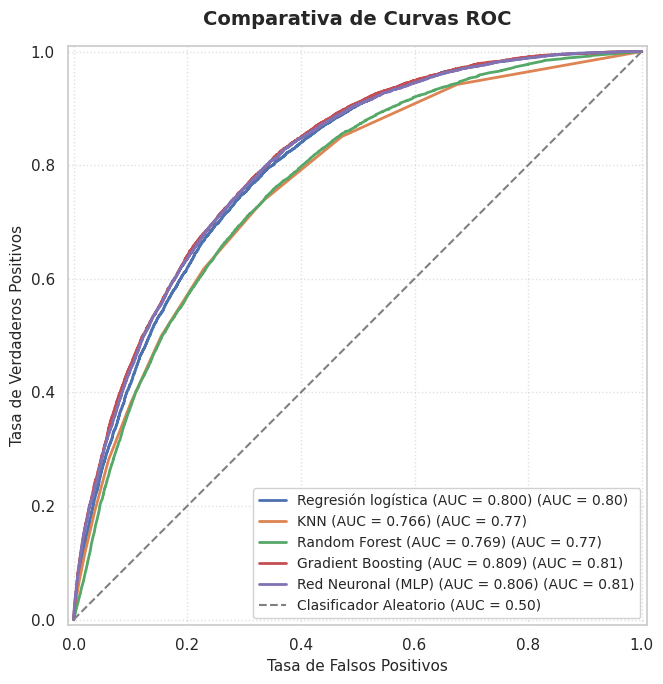

In [0]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

# Se crea la figura
fig, ax = plt.subplots(figsize=(9, 7))


for nombre_modelo, y_proba in prob_modelos.items():
    # Calcular el valor exacto de AUC-ROC
    auc_val = roc_auc_score(y_test, y_proba)
    
    # Dibujar la curva e incluir el AUC en la leyenda
    RocCurveDisplay.from_predictions(
        y_test,
        y_proba,
        name=f"{nombre_modelo} (AUC = {auc_val:.3f})",
        ax=ax,
        linewidth=2
    )

# Dibujar un clasificador aleatorio como comparativa
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1.5, label='Clasificador Aleatorio (AUC = 0.50)')

# Personalización estética
ax.set_title('Comparativa de Curvas ROC', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9, fontsize=10)


plt.tight_layout()
plt.show()

> Probablemente, la principal conclusión que podemos obetenr de este análisis es que: los cinco modelos son capaces de ordenar el riesgo de manera bastante decente, sin embargo, en función de si el algortimo cuenta con un algoritmo de balanceo de manera nativa o no, la sensibilidad del modelo varía de forma abrumadora, pasando del 18% en modelos que no cuentan con ello, al 75% en aquellos que sí.

### 5.8. Evaluación y validación de modelos de aprendizaje automático

Igual que hicimos en el 5.7, procedemos a crear una función para ajustar los umbrales de los modelos que no contaban con un balanceo de clases nativo. Esto nos ayudará a incrementar la sensibilidad del modelo, no sin ello sacrificar precisión.

> Es importante que la validación cruzada se use únicamente sobre el conjunto de train, de otro modo, estaríamos *"espiando"* los datos a predecir, e incurriríamos en un error de **fuga de datos**, ya que, estaríamos consiguiendo números increíbles haciendo trampa. El modelo se sobreajustaría a los datos ya conocidos y al incluir nuevos datos en el modelo no sería capaz de predecirlos correctamente, puesto que ya aprendió con las respuestas dadas.

In [0]:
%%writefile umbral_optimo.py

import numpy as np
import pandas as pd

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score, precision_recall_curve

 
def umbral_optimo_cv(modelo, X_train, y_train, cv=5):
    """
    Calcula, mediante validación cruzada sobre TRAIN, las probabilidades predichas y busca el umbral que maximiza el F1 de la clase positiva.

    """
    probas_oof = cross_val_predict(
        modelo, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
    )[:, 1]
 
    precision, recall, thresholds = precision_recall_curve(y_train, probas_oof)
    precision, recall = precision[:-1], recall[:-1]
 
    f1_scores = np.where(
        (precision + recall) > 0,
        2 * precision * recall / (precision + recall),
        0
    )
    idx_mejor = np.argmax(f1_scores)
    mejor_umbral = thresholds[idx_mejor]
 
    print(f"Umbral óptimo (CV, maximiza F1): {mejor_umbral:.3f}")
    print(f"  -> En CV: precision={precision[idx_mejor]:.3f}, "
          f"recall={recall[idx_mejor]:.3f}, f1={f1_scores[idx_mejor]:.3f}")
 
    return mejor_umbral

Overwriting umbral_optimo.py


In [0]:
umbrales_modelos = {}

- **K-Nearest Neighbors**

In [0]:
import sys
import importlib
import time
import pandas as pd
import joblib

from sklearn.neighbors import KNeighborsClassifier

sys.path.append('.')
import umbral_optimo
importlib.reload(umbral_optimo)

from umbral_optimo import umbral_optimo_cv

X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv").squeeze()

knn = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)

t0 = time.time()
umbral_knn = umbral_optimo_cv(knn, X_train, y_train, cv=5)
print(f"Tiempo total: {time.time()-t0:.1f}s")

umbrales_modelos["KNN"] = umbral_knn

joblib.dump(umbral_knn, "umbral_knn.pkl")

Umbral óptimo (CV, maximiza F1): 0.267
  -> En CV: precision=0.356, recall=0.629, f1=0.455
Tiempo total: 75.2s


['umbral_knn.pkl']

> Se puede observar como el umbral óptimo para maximizar sensibilidad se situaría en 0,267, cuando por defecto el modelo le aplicaba un 0,5.

In [0]:
import sys
import importlib
import pandas as pd
import joblib

from sklearn.neighbors import KNeighborsClassifier

sys.path.append('.')
import evaluacion
importlib.reload(evaluacion)

from evaluacion import evaluar_modelo

X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

knn = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
knn.fit(X_train, y_train)

umbral_knn = joblib.load("umbral_knn.pkl")
y_proba_knn = knn.predict_proba(X_test)[:, 1]
y_pred_umbral = (y_proba_knn >= umbral_knn).astype(int)

evaluar_modelo(
    nombre="KNN (Umbral Óptimo)", 
    modelo=knn, 
    X_test=X_test, 
    y_test=y_test, 
    y_pred=y_pred_umbral, 
    y_proba=y_proba_knn
)

prob_modelos['KNN (Umbral Óptimo)'] = y_proba_knn
resultados["KNN (Umbral Óptimo)"] = evaluar_modelo(
    nombre="KNN (Umbral Óptimo)", 
    modelo=knn, 
    X_test=X_test, 
    y_test=y_test, 
    y_pred=y_pred_umbral, 
    y_proba=y_proba_knn
)

--- KNN (Umbral Óptimo) ---
accuracy  : 0.7446
precision : 0.3602
recall    : 0.6172
f1        : 0.4549
auc_roc   : 0.7663

Matriz de confusión:
[[29313  8698]
 [ 3036  4896]]

                   precision    recall  f1-score   support

     Sin diabetes       0.91      0.77      0.83     38011
Diabetes/prediab.       0.36      0.62      0.45      7932

         accuracy                           0.74     45943
        macro avg       0.63      0.69      0.64     45943
     weighted avg       0.81      0.74      0.77     45943

------------------------------------------------------------
--- KNN (Umbral Óptimo) ---
accuracy  : 0.7446
precision : 0.3602
recall    : 0.6172
f1        : 0.4549
auc_roc   : 0.7663

Matriz de confusión:
[[29313  8698]
 [ 3036  4896]]

                   precision    recall  f1-score   support

     Sin diabetes       0.91      0.77      0.83     38011
Diabetes/prediab.       0.36      0.62      0.45      7932

         accuracy                           0.74 

Con ese umbral, en validación cruzada obtenemos F1=0,452 (precision 35,8%, recall 61,4%) — mucho mejor equilibrio que el recall de 18,4% que veíamos antes.

- **Random Forest**

In [0]:
import sys
import importlib
import time
import pandas as pd
import joblib

from sklearn.ensemble import RandomForestClassifier

sys.path.append('.')
import umbral_optimo
importlib.reload(umbral_optimo)

X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv").squeeze()

rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)

t0 = time.time()
umbral_rf = umbral_optimo_cv(rf, X_train, y_train, cv=5)
print(f"Tiempo total: {time.time()-t0:.1f}s")

umbrales_modelos["Random Forest"] = umbral_rf

joblib.dump(umbral_rf, "umbral_rf.pkl")

/databricks/python/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Workspace/Users/adrian97880@gmail.com/Drafts/Master/umbral_optimo.py:23: RuntimeWarning: invalid value encountered in divide
  2 * precision * recall / (precision + recall),


Umbral óptimo (CV, maximiza F1): 0.230
  -> En CV: precision=0.356, recall=0.635, f1=0.457
Tiempo total: 219.3s


['umbral_rf.pkl']

In [0]:
import sys
import importlib
import pandas as pd
import joblib

from sklearn.ensemble import RandomForestClassifier

sys.path.append('.')
import evaluacion
importlib.reload(evaluacion)

from evaluacion import evaluar_modelo

X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

umbral_rf = joblib.load("umbral_rf.pkl")
y_proba_rf = rf.predict_proba(X_test)[:, 1]
y_pred_umbral = (y_proba_rf >= umbral_rf).astype(int)

evaluar_modelo(
    nombre="Random Forest (Umbral Óptimo)", 
    modelo=rf, 
    X_test=X_test, 
    y_test=y_test, 
    y_pred=y_pred_umbral, 
    y_proba=y_proba_rf
)

prob_modelos['Random Forest (Umbral Óptimo)'] = y_proba_rf
resultados['Random Forest (Umbral Óptimo)'] = evaluar_modelo(
    nombre="Random Forest (Umbral Óptimo)", 
    modelo=rf, 
    X_test=X_test, 
    y_test=y_test, 
    y_pred=y_pred_umbral, 
    y_proba=y_proba_rf
)

--- Random Forest (Umbral Óptimo) ---
accuracy  : 0.7412
precision : 0.3565
recall    : 0.6198
f1        : 0.4526
auc_roc   : 0.7692

Matriz de confusión:
[[29136  8875]
 [ 3016  4916]]

                   precision    recall  f1-score   support

     Sin diabetes       0.91      0.77      0.83     38011
Diabetes/prediab.       0.36      0.62      0.45      7932

         accuracy                           0.74     45943
        macro avg       0.63      0.69      0.64     45943
     weighted avg       0.81      0.74      0.77     45943

------------------------------------------------------------
--- Random Forest (Umbral Óptimo) ---
accuracy  : 0.7412
precision : 0.3565
recall    : 0.6198
f1        : 0.4526
auc_roc   : 0.7692

Matriz de confusión:
[[29136  8875]
 [ 3016  4916]]

                   precision    recall  f1-score   support

     Sin diabetes       0.91      0.77      0.83     38011
Diabetes/prediab.       0.36      0.62      0.45      7932

         accuracy            

En este caso, se puede observar como para Random Forest, el umbral óptimo fue de 0.242; otorgando unos resultados muy similares a KNN con una **recall de 0,5696**, **precisión del 36%** y **F1 de 0,451**.

- **Red Neuronal**

In [0]:
import sys
import importlib
import time
import pandas as pd
import joblib

from sklearn.neural_network import MLPClassifier

sys.path.append('.')
import umbral_optimo
importlib.reload(umbral_optimo)

X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv").squeeze()

mlp = MLPClassifier(hidden_layer_sizes=(32,16), activation='relu', max_iter=200, random_state=42, early_stopping=True)

t0 = time.time()
umbral_mlp = umbral_optimo_cv(mlp, X_train, y_train, cv=5)
print(f"Tiempo total: {time.time()-t0:.1f}s")

umbrales_modelos["MLP"] = umbral_mlp

joblib.dump(umbral_mlp, "umbral_mlp.pkl")

Umbral óptimo (CV, maximiza F1): 0.261
  -> En CV: precision=0.405, recall=0.621, f1=0.490
Tiempo total: 18.5s


/Workspace/Users/adrian97880@gmail.com/Drafts/Master/umbral_optimo.py:23: RuntimeWarning: invalid value encountered in divide
  2 * precision * recall / (precision + recall),


['umbral_mlp.pkl']

In [0]:
import sys
import importlib
import pandas as pd
import joblib

from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight

sys.path.append('.')
import evaluacion
importlib.reload(evaluacion)

from evaluacion import evaluar_modelo

X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

MLP = MLPClassifier(
    hidden_layer_sizes=(32,16), activation='relu', max_iter=200,
    random_state=42, early_stopping=True
)
MLP.fit(X_train, y_train)

umbral_MLP = joblib.load("umbral_mlp.pkl")
y_proba_MLP = MLP.predict_proba(X_test)[:, 1]
y_pred_umbral = (y_proba_MLP >= umbral_MLP).astype(int)

evaluar_modelo(
    nombre="MLP (Umbral Óptimo)", 
    modelo=MLP, 
    X_test=X_test, 
    y_test=y_test, 
    y_pred=y_pred_umbral, 
    y_proba=y_proba_MLP
)

prob_modelos['MLP (Umbral Óptimo)'] = y_proba_MLP
resultados['MLP (Umbral Óptimo)'] = evaluar_modelo(
    nombre="MLP (Umbral Óptimo)", 
    modelo=MLP, 
    X_test=X_test, 
    y_test=y_test, 
    y_pred=y_pred_umbral, 
    y_proba=y_proba_MLP
)

--- MLP (Umbral Óptimo) ---
accuracy  : 0.7758
precision : 0.4035
recall    : 0.6242
f1        : 0.4902
auc_roc   : 0.8063

Matriz de confusión:
[[30693  7318]
 [ 2981  4951]]

                   precision    recall  f1-score   support

     Sin diabetes       0.91      0.81      0.86     38011
Diabetes/prediab.       0.40      0.62      0.49      7932

         accuracy                           0.78     45943
        macro avg       0.66      0.72      0.67     45943
     weighted avg       0.82      0.78      0.79     45943

------------------------------------------------------------
--- MLP (Umbral Óptimo) ---
accuracy  : 0.7758
precision : 0.4035
recall    : 0.6242
f1        : 0.4902
auc_roc   : 0.8063

Matriz de confusión:
[[30693  7318]
 [ 2981  4951]]

                   precision    recall  f1-score   support

     Sin diabetes       0.91      0.81      0.86     38011
Diabetes/prediab.       0.40      0.62      0.49      7932

         accuracy                           0.78 

Para el caso de la red neuronal, el umbral se sitúa aproximádamente en la misma zona, 0,257, otorgando valores realmente similares a los anteriores modelos, con una **sensibilidad en torno al 59%**.

> Lo que podemos extraer de este análisis, es que en todos los casos, el AUC-ROC del modelo se mantiene, lo  único que estamos haciendo, es enseñarle dónde queremos establecer el corte para que el resto de parámetros de nuestro modelo, se ajusten a la clase que queremos predecir, no sin sacrificar otros por el camino.

### 5.9. Comparativa de resultados

In [0]:
# Creo una tabla con los umbrales óptimos de cada modelo
df_umbrales = pd.DataFrame(umbrales_modelos, index=['Resultdos']).T
df_umbrales =df_umbrales.sort_values(by='Resultdos', ascending=False)
df_umbrales_style = df_umbrales.style.format("{:.4f}").background_gradient(cmap="Blues")
df_umbrales_style

,Resultdos
KNN,0.2667
MLP,0.2610
Random Forest,0.2297


In [0]:
# Convierto el diccionario en un DataFrame y lo transpongo (.T)
# Transponer sirve para que cada modelo sea una FILA y cada métrica una COLUMNA
df_resultados = pd.DataFrame(resultados).T

# Ordenar los modelos de mayor a menor según Recall
df_resultados = df_resultados.sort_values(by="recall", ascending=False)

# Formateo la visualización con 4 decimales
df_resultados_style = df_resultados.style.format("{:.4f}").background_gradient(cmap="Blues", subset=["recall", "auc_roc"])

df_resultados_style

,accuracy,precision,recall,f1,auc_roc
Gradient Boosting,0.7101,0.3457,0.7603,0.4753,0.8089
Regresión Logística,0.7180,0.3497,0.7374,0.4744,0.8004
MLP (Umbral Óptimo),0.7758,0.4035,0.6242,0.4902,0.8063
Random Forest (Umbral Óptimo),0.7412,0.3565,0.6198,0.4526,0.7692
KNN (Umbral Óptimo),0.7446,0.3602,0.6172,0.4549,0.7663
Red Neuronal (MLP),0.8386,0.5968,0.2005,0.3001,0.8063
KNN,0.8296,0.5174,0.1913,0.2793,0.7663
Random Forest,0.8235,0.4716,0.1853,0.2661,0.7692


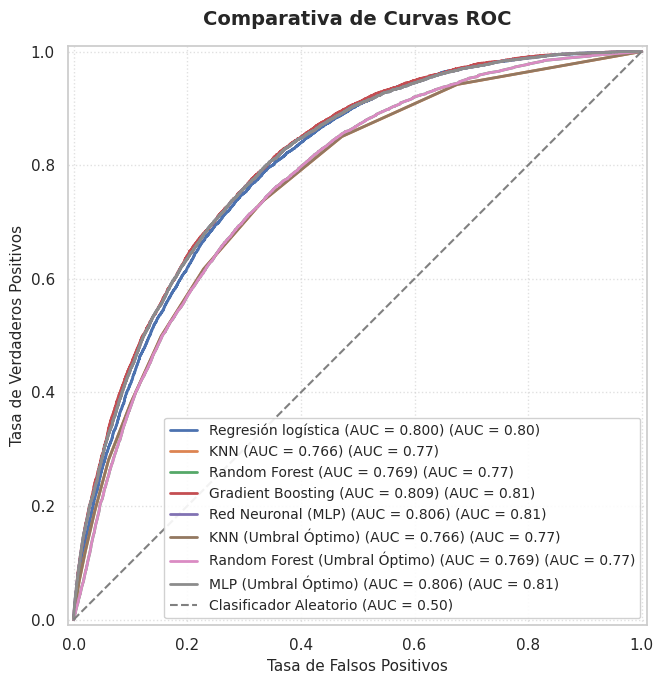

In [0]:
# Se crea la figura
fig, ax = plt.subplots(figsize=(9, 7))


for nombre_modelo, y_proba in prob_modelos.items():
    # Calcular el valor exacto de AUC-ROC
    auc_val = roc_auc_score(y_test, y_proba)
    
    # Dibujar la curva e incluir el AUC en la leyenda
    RocCurveDisplay.from_predictions(
        y_test,
        y_proba,
        name=f"{nombre_modelo} (AUC = {auc_val:.3f})",
        ax=ax,
        linewidth=2
    )

# Dibujar un clasificador aleatorio como comparativa
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1.5, label='Clasificador Aleatorio (AUC = 0.50)')

# Personalización estética
ax.set_title('Comparativa de Curvas ROC', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9, fontsize=10)


plt.tight_layout()
plt.show()